# Chapter 34 — Gradient Descent With Multiple Parameters

## Learning goals

Chapter 33 trained a model with one parameter.

This chapter trains a line model with two parameters:

```python
prediction = weight * input_number + bias
```

By the end of this chapter, you should be able to:

1. Explain the roles of weight and bias in a line model.
2. Compute predictions and average squared error loss over a small dataset.
3. Compute the partial derivative for each parameter.
4. Numerically check both gradient components.
5. Update weight and bias simultaneously with gradient descent.
6. Print and interpret every training step.
7. Plot loss and parameter values during training.
8. Plot the line before, during, and after training.
9. Explain why parameter gradients and update sizes can differ.
10. Explain how input scale and learning rate affect training stability.

## The tiny dataset and line model

We train on three input-target pairs:

```python
inputs = [1, 2, 3]
targets = [3, 5, 7]
```

They follow `target = 2 × input + 1`, so the exact parameters are weight `2` and bias `1`.

The point is not to guess those values but to watch gradient descent recover them from imperfect starting parameters.

## Terms used in this chapter

- A **weight** multiplies the input and controls the line's slope.
- A **bias** is added to the weighted input and controls the line's vertical shift.
- A **partial derivative** measures how loss changes with one parameter while the others are held fixed.
- A **gradient** is the collection of all parameter partial derivatives.
- **Average squared error loss** averages squared prediction errors across examples.
- A **simultaneous update** computes all gradients at the old parameter values before changing any parameter.

For two parameters, the gradient can be written as the pair `(weight_gradient, bias_gradient)`.

## Create and inspect the dataset

Each input must have one corresponding target.

In [1]:
inputs = [1.0, 2.0, 3.0]
targets = [3.0, 5.0, 7.0]

assert len(inputs) == len(targets)

print("input | target")
print("-" * 16)

for input_number, target_number in zip(inputs, targets, strict=True):
    print(f"{input_number:>5.1f} | {target_number:>6.1f}")

input | target
----------------
  1.0 |    3.0
  2.0 |    5.0
  3.0 |    7.0


The target rises by `2` whenever the input rises by `1`, and the line would cross the vertical axis at `1`.

## Define predictions and loss

The model predicts one number for each input.

The dataset loss averages the squared errors, so every example contributes equally.

In [2]:
def validate_dataset(inputs: list[float], targets: list[float]) -> None:
    if len(inputs) != len(targets):
        raise ValueError("inputs and targets must have the same length.")

    if len(inputs) == 0:
        raise ValueError("inputs and targets must not be empty.")


def predict_with_weight_and_bias(
    input_number: float,
    weight: float,
    bias: float,
) -> float:
    return weight * input_number + bias


def average_squared_error_loss(
    inputs: list[float],
    targets: list[float],
    weight: float,
    bias: float,
) -> float:
    validate_dataset(inputs, targets)
    total_loss = 0.0

    for input_number, target_number in zip(inputs, targets, strict=True):
        prediction = predict_with_weight_and_bias(input_number, weight, bias)
        error = prediction - target_number
        total_loss += error**2

    return total_loss / len(inputs)

Start with weight `0` and bias `0`.

This line predicts `0` for every input, so its errors are large.

In [3]:
starting_weight = 0.0
starting_bias = 0.0

print("input | target | prediction | error | squared error")
print("-" * 58)

for input_number, target_number in zip(inputs, targets, strict=True):
    prediction = predict_with_weight_and_bias(
        input_number,
        starting_weight,
        starting_bias,
    )
    error = prediction - target_number
    print(
        f"{input_number:>5.1f} | "
        f"{target_number:>6.1f} | "
        f"{prediction:>10.4f} | "
        f"{error:>7.4f} | "
        f"{error**2:>13.4f}"
    )

starting_loss = average_squared_error_loss(
    inputs,
    targets,
    starting_weight,
    starting_bias,
)
print()
print("Starting average loss:", starting_loss)

input | target | prediction | error | squared error
----------------------------------------------------------
  1.0 |    3.0 |     0.0000 | -3.0000 |        9.0000
  2.0 |    5.0 |     0.0000 | -5.0000 |       25.0000
  3.0 |    7.0 |     0.0000 | -7.0000 |       49.0000

Starting average loss: 27.666666666666668


The average loss is `83 / 3`, or approximately `27.67`.

Training seeks one parameter pair that lowers the average error across all three examples.

## Derive both gradient components

For one example, let `error = prediction - target`.

The two partial derivatives are:

```text
weight gradient part = 2 × error × input
bias gradient part   = 2 × error
```

Changing bias changes prediction directly, while changing weight changes prediction in proportion to the input.

Because the loss is an average, we average each gradient part across the dataset.

In [4]:
def compute_gradients_for_weight_and_bias(
    inputs: list[float],
    targets: list[float],
    weight: float,
    bias: float,
) -> tuple[float, float]:
    validate_dataset(inputs, targets)
    weight_gradient_total = 0.0
    bias_gradient_total = 0.0

    for input_number, target_number in zip(inputs, targets, strict=True):
        prediction = predict_with_weight_and_bias(input_number, weight, bias)
        error = prediction - target_number
        weight_gradient_total += 2 * error * input_number
        bias_gradient_total += 2 * error

    number_of_examples = len(inputs)
    weight_gradient = weight_gradient_total / number_of_examples
    bias_gradient = bias_gradient_total / number_of_examples

    return weight_gradient, bias_gradient

Print each example's contribution at the starting parameters.

In [5]:
print("input | target | prediction | error | weight gradient part | bias gradient part")
print("-" * 90)

for input_number, target_number in zip(inputs, targets, strict=True):
    prediction = predict_with_weight_and_bias(
        input_number,
        starting_weight,
        starting_bias,
    )
    error = prediction - target_number
    print(
        f"{input_number:>5.1f} | "
        f"{target_number:>6.1f} | "
        f"{prediction:>10.4f} | "
        f"{error:>7.4f} | "
        f"{2 * error * input_number:>20.4f} | "
        f"{2 * error:>18.4f}"
    )

starting_weight_gradient, starting_bias_gradient = (
    compute_gradients_for_weight_and_bias(
        inputs,
        targets,
        starting_weight,
        starting_bias,
    )
)

print()
print("Average weight gradient:", starting_weight_gradient)
print("Average bias gradient:", starting_bias_gradient)

input | target | prediction | error | weight gradient part | bias gradient part
------------------------------------------------------------------------------------------
  1.0 |    3.0 |     0.0000 | -3.0000 |              -6.0000 |            -6.0000
  2.0 |    5.0 |     0.0000 | -5.0000 |             -20.0000 |           -10.0000
  3.0 |    7.0 |     0.0000 | -7.0000 |             -42.0000 |           -14.0000

Average weight gradient: -22.666666666666668
Average bias gradient: -10.0


Both components are negative, so a small increase in either parameter lowers loss locally.

Their magnitudes differ because each parameter affects predictions differently.

## Check both partial derivatives numerically

Hold bias fixed while nudging weight, then hold weight fixed while nudging bias.

These two independent checks test the two components of the analytical gradient.

In [6]:
small_change = 0.0001

numerical_weight_gradient = (
    average_squared_error_loss(
        inputs,
        targets,
        starting_weight + small_change,
        starting_bias,
    )
    - average_squared_error_loss(
        inputs,
        targets,
        starting_weight - small_change,
        starting_bias,
    )
) / (2 * small_change)

numerical_bias_gradient = (
    average_squared_error_loss(
        inputs,
        targets,
        starting_weight,
        starting_bias + small_change,
    )
    - average_squared_error_loss(
        inputs,
        targets,
        starting_weight,
        starting_bias - small_change,
    )
) / (2 * small_change)

print("Weight gradient: numerical =", numerical_weight_gradient)
print("Weight gradient: exact     =", starting_weight_gradient)
print("Bias gradient: numerical   =", numerical_bias_gradient)
print("Bias gradient: exact       =", starting_bias_gradient)

assert abs(numerical_weight_gradient - starting_weight_gradient) < 1e-8
assert abs(numerical_bias_gradient - starting_bias_gradient) < 1e-8

Weight gradient: numerical = -22.666666666673052
Weight gradient: exact     = -22.666666666666668
Bias gradient: numerical   = -9.999999999976694
Bias gradient: exact       = -10.0


The numerical and exact values agree to floating-point precision.

This is a useful correctness check, not the method used for every update.

## Update both parameters simultaneously

Compute both gradients at the same old weight and bias, then apply both updates:

```python
updated_weight = weight - learning_rate * weight_gradient
updated_bias = bias - learning_rate * bias_gradient
```

Updating weight before computing the bias gradient would evaluate the two components at different points and would no longer be one standard gradient-descent step.

In [7]:
learning_rate = 0.05

updated_weight = starting_weight - learning_rate * starting_weight_gradient
updated_bias = starting_bias - learning_rate * starting_bias_gradient

updated_loss = average_squared_error_loss(
    inputs,
    targets,
    updated_weight,
    updated_bias,
)

print("Old parameters:", (starting_weight, starting_bias))
print("Gradient:", (starting_weight_gradient, starting_bias_gradient))
print("Updated parameters:", (updated_weight, updated_bias))
print("Old loss:", starting_loss)
print("Updated loss:", updated_loss)

assert updated_loss < starting_loss

Old parameters: (0.0, 0.0)
Gradient: (-22.666666666666668, -10.0)
Updated parameters: (1.1333333333333335, 0.5)
Old loss: 27.666666666666668
Updated loss: 5.488518518518517


The first weight update is larger because its gradient magnitude is larger under this data scale and shared learning rate.

That observation describes this step, not a permanent ordering of how fast the parameters must move.

## Train repeatedly and retain the final parameters

As in Chapter 33, each history record stores values before its update.

The function separately returns the final post-update weight and bias.

In [8]:
def train_line_model(
    inputs: list[float],
    targets: list[float],
    initial_weight: float,
    initial_bias: float,
    learning_rate: float,
    number_of_steps: int,
) -> tuple[list[dict[str, float]], float, float]:
    validate_dataset(inputs, targets)

    if learning_rate <= 0:
        raise ValueError("learning_rate must be positive.")

    if number_of_steps < 1:
        raise ValueError("number_of_steps must be at least 1.")

    weight = initial_weight
    bias = initial_bias
    history = []

    for step in range(number_of_steps):
        loss = average_squared_error_loss(inputs, targets, weight, bias)
        weight_gradient, bias_gradient = compute_gradients_for_weight_and_bias(
            inputs,
            targets,
            weight,
            bias,
        )
        updated_weight = weight - learning_rate * weight_gradient
        updated_bias = bias - learning_rate * bias_gradient

        history.append(
            {
                "step": step,
                "weight": weight,
                "bias": bias,
                "loss": loss,
                "weight_gradient": weight_gradient,
                "bias_gradient": bias_gradient,
                "updated_weight": updated_weight,
                "updated_bias": updated_bias,
            }
        )

        weight = updated_weight
        bias = updated_bias

    return history, weight, bias

Print every step of a short run so both updates remain visible.

In [9]:
def print_training_history(history: list[dict[str, float]]) -> None:
    print(
        "step | weight | bias | loss | "
        "weight grad | bias grad | updated weight | updated bias"
    )
    print("-" * 112)

    for row in history:
        print(
            f"{int(row['step']):>4} | "
            f"{row['weight']:>8.5f} | "
            f"{row['bias']:>8.5f} | "
            f"{row['loss']:>10.6f} | "
            f"{row['weight_gradient']:>11.6f} | "
            f"{row['bias_gradient']:>9.6f} | "
            f"{row['updated_weight']:>14.6f} | "
            f"{row['updated_bias']:>12.6f}"
        )


short_history, _, _ = train_line_model(
    inputs,
    targets,
    initial_weight=0.0,
    initial_bias=0.0,
    learning_rate=0.05,
    number_of_steps=15,
)

print_training_history(short_history)

step | weight | bias | loss | weight grad | bias grad | updated weight | updated bias
----------------------------------------------------------------------------------------------------------------
   0 |  0.00000 |  0.00000 |  27.666667 |  -22.666667 | -10.000000 |       1.133333 |     0.500000
   1 |  1.13333 |  0.50000 |   5.488519 |  -10.088889 | -4.466667 |       1.637778 |     0.723333
   2 |  1.63778 |  0.72333 |   1.089693 |   -4.487407 | -2.002222 |       1.862148 |     0.823444
   3 |  1.86215 |  0.82344 |   0.217207 |   -1.992840 | -0.904519 |       1.961790 |     0.868670
   4 |  1.96179 |  0.86867 |   0.044133 |   -0.881944 | -0.415499 |       2.005887 |     0.889445
   5 |  2.00589 |  0.88945 |   0.009781 |   -0.387270 | -0.197560 |       2.025251 |     0.899323
   6 |  2.02525 |  0.89932 |   0.002943 |   -0.167032 | -0.100350 |       2.033602 |     0.904341
   7 |  2.03360 |  0.90434 |   0.001562 |   -0.069014 | -0.056909 |       2.037053 |     0.907186
   8 |  2.03705 

The loss falls on every displayed step, but weight and bias do not approach their final values at identical rates.

## Run long enough to recover the line

The line's slope and intercept interact, so use 500 steps to approach both exact values closely.

In [10]:
history, final_weight, final_bias = train_line_model(
    inputs,
    targets,
    initial_weight=0.0,
    initial_bias=0.0,
    learning_rate=0.05,
    number_of_steps=500,
)

final_loss = average_squared_error_loss(
    inputs,
    targets,
    final_weight,
    final_bias,
)

print("Final weight:", final_weight)
print("Final bias:", final_bias)
print("Final average loss:", final_loss)

assert abs(final_weight - 2.0) < 0.001
assert abs(final_bias - 1.0) < 0.003
assert final_loss < 1e-6

Final weight: 2.000104850952742
Final bias: 0.9997616491392355
Final average loss: 8.149910832601979e-09


The trained parameters are close to weight `2` and bias `1`, and the average loss is close to zero.

## Plot loss and both parameters

The first panel shows optimization progress.

The second panel shows that weight and bias follow different trajectories toward their exact values.

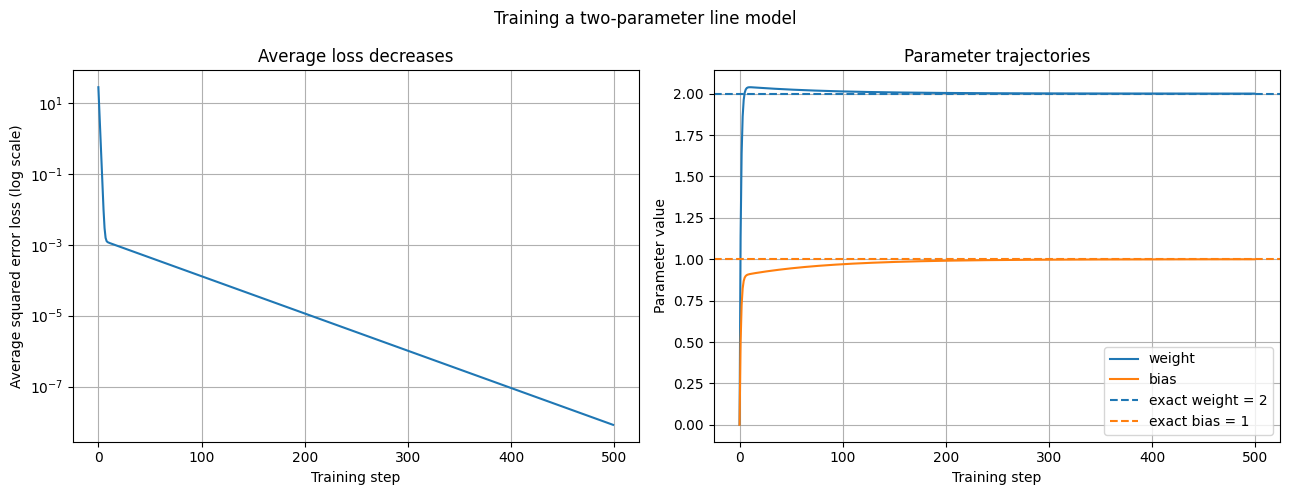

In [11]:
import matplotlib.pyplot as plt

steps = [int(row["step"]) for row in history]
losses = [row["loss"] for row in history]
weights = [row["weight"] for row in history]
biases = [row["bias"] for row in history]

figure, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(steps, losses)
axes[0].set_yscale("log")
axes[0].set_title("Average loss decreases")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Average squared error loss (log scale)")
axes[0].grid(True)

axes[1].plot(steps, weights, label="weight")
axes[1].plot(steps, biases, label="bias")
axes[1].axhline(2.0, linestyle="--", color="tab:blue", label="exact weight = 2")
axes[1].axhline(1.0, linestyle="--", color="tab:orange", label="exact bias = 1")
axes[1].set_title("Parameter trajectories")
axes[1].set_xlabel("Training step")
axes[1].set_ylabel("Parameter value")
axes[1].legend()
axes[1].grid(True)

figure.suptitle("Training a two-parameter line model")
figure.tight_layout()
plt.show()

Loss drops quickly at first, while the final adjustment of the two interacting parameters takes longer.

## Plot the line before, during, and after training

One figure compares all three snapshots against the data points.

This avoids separating one visual story across several redundant plots.

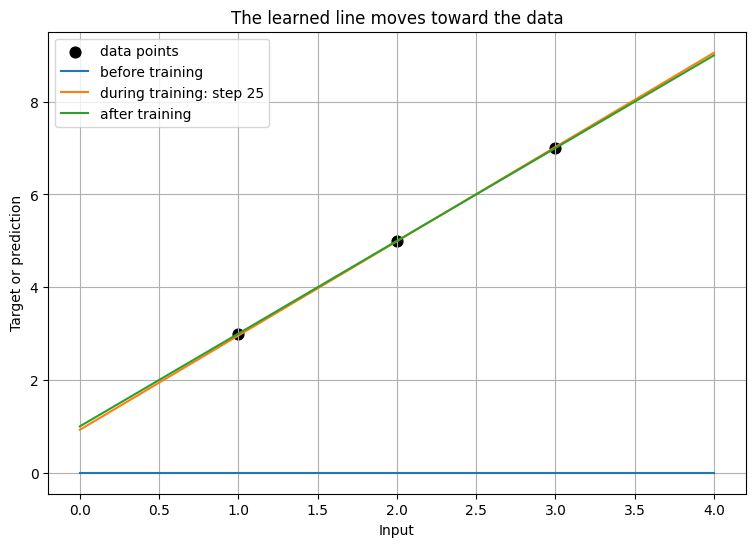

Middle parameters: (2.0327437136502704, 0.9255658333193666)
Final parameters: (2.000104850952742, 0.9997616491392355)


In [12]:
def make_line_predictions(
    x_values: list[float],
    weight: float,
    bias: float,
) -> list[float]:
    return [predict_with_weight_and_bias(x, weight, bias) for x in x_values]


x_values_for_line = [step * 0.1 for step in range(41)]
middle_step = 25
middle_weight = history[middle_step]["weight"]
middle_bias = history[middle_step]["bias"]

initial_line = make_line_predictions(x_values_for_line, 0.0, 0.0)
middle_line = make_line_predictions(
    x_values_for_line,
    middle_weight,
    middle_bias,
)
final_line = make_line_predictions(
    x_values_for_line,
    final_weight,
    final_bias,
)

plt.figure(figsize=(9, 6))
plt.scatter(inputs, targets, color="black", s=60, label="data points")
plt.plot(x_values_for_line, initial_line, label="before training")
plt.plot(
    x_values_for_line,
    middle_line,
    label=f"during training: step {middle_step}",
)
plt.plot(x_values_for_line, final_line, label="after training")
plt.xlabel("Input")
plt.ylabel("Target or prediction")
plt.title("The learned line moves toward the data")
plt.legend()
plt.grid(True)
plt.show()

print("Middle parameters:", (middle_weight, middle_bias))
print("Final parameters:", (final_weight, final_bias))

The initial line is flat at zero.

The middle line is closer, and the final line passes almost exactly through the data.

## Inspect final predictions

The final parameter values matter because of the predictions they produce.

In [13]:
print("input | target | final prediction | error")
print("-" * 47)

for input_number, target_number in zip(inputs, targets, strict=True):
    final_prediction = predict_with_weight_and_bias(
        input_number,
        final_weight,
        final_bias,
    )
    print(
        f"{input_number:>5.1f} | "
        f"{target_number:>6.1f} | "
        f"{final_prediction:>16.8f} | "
        f"{final_prediction - target_number:>10.8f}"
    )

input | target | final prediction | error
-----------------------------------------------
  1.0 |    3.0 |       2.99986650 | -0.00013350
  2.0 |    5.0 |       4.99997135 | -0.00002865
  3.0 |    7.0 |       7.00007620 | 0.00007620


Every prediction is close to its target, so the fitted line has low dataset loss.

## Gradient sizes depend on parameter role and data scale

At the start, the weight gradient has greater magnitude because each weight contribution includes the input.

With one shared learning rate:

```text
weight update magnitude = learning rate × |weight gradient|
bias update magnitude   = learning rate × |bias gradient|
```

Therefore, larger current gradient magnitude means a larger immediate update.

This does not mean weight always learns faster, because gradients change after every update and depend on the units and scale of the data.

In [14]:
large_inputs = [100.0, 200.0, 300.0]
large_targets = [201.0, 401.0, 601.0]

large_scale_weight_gradient, large_scale_bias_gradient = (
    compute_gradients_for_weight_and_bias(
        large_inputs,
        large_targets,
        weight=0.0,
        bias=0.0,
    )
)

print("Original-scale gradients:")
print((starting_weight_gradient, starting_bias_gradient))
print()
print("Large-input gradients:")
print((large_scale_weight_gradient, large_scale_bias_gradient))

Original-scale gradients:
(-22.666666666666668, -10.0)

Large-input gradients:
(-187066.66666666666, -802.0)


The weight gradient becomes enormous because it is multiplied by much larger inputs.

This is one reason feature scale can change which learning rates are safe.

## Learning rate still controls stability

Multiple parameters do not remove the learning-rate problem.

Compare a useful rate with a very small rate and an unstable large rate.

In [15]:
rates_to_compare = {
    "too small: 0.001": 0.001,
    "useful: 0.05": 0.05,
    "too large: 0.5": 0.5,
}

rate_histories = {}

print("rate | initial loss | loss at step 19")
print("-" * 42)

for label, rate in rates_to_compare.items():
    rate_history, _, _ = train_line_model(
        inputs,
        targets,
        initial_weight=0.0,
        initial_bias=0.0,
        learning_rate=rate,
        number_of_steps=20,
    )
    rate_histories[label] = rate_history
    print(
        f"{rate:>4.3f} | "
        f"{rate_history[0]['loss']:>12.6f} | "
        f"{rate_history[-1]['loss']:>15.6f}"
    )

rate | initial loss | loss at step 19
------------------------------------------
0.001 |    27.666667 |       18.108260
0.050 |    27.666667 |        0.000919
0.500 |    27.666667 | 271368159061752995018440704.000000


The small rate improves slowly, the useful rate lowers loss substantially, and the large rate diverges.

As parameters move farther away, gradients grow and produce still larger updates.

## Plot the learning-rate comparison

A logarithmic axis keeps the stable and exploding runs visible together.

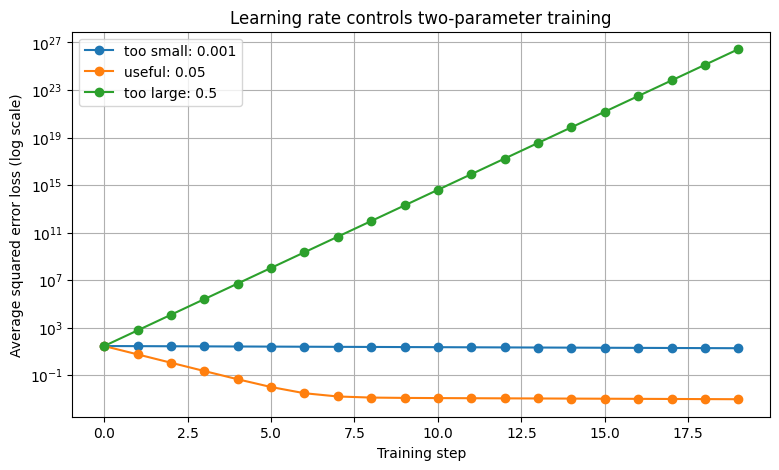

In [16]:
plt.figure(figsize=(9, 5))

for label, rate_history in rate_histories.items():
    rate_steps = [int(row["step"]) for row in rate_history]
    rate_losses = [row["loss"] for row in rate_history]
    plt.plot(rate_steps, rate_losses, marker="o", label=label)

plt.yscale("log")
plt.xlabel("Training step")
plt.ylabel("Average squared error loss (log scale)")
plt.title("Learning rate controls two-parameter training")
plt.legend()
plt.grid(True)
plt.show()

The same learning rate can also behave very differently after input rescaling, because rescaling changes the loss curvature and gradients.

## From two parameters to parameter arrays

The update idea has not changed:

```text
new parameter = old parameter - learning rate × parameter gradient
```

With two parameters, the gradient contains two components.

With vectors, matrices, and tensors of parameters, every learned number has a corresponding gradient with the same array shape.

Libraries apply these elementwise updates without requiring a separate handwritten assignment for every number.

## A clean two-parameter training pipeline

This final cell checks the complete result using the reusable training functions.

In [17]:
pipeline_history, pipeline_weight, pipeline_bias = train_line_model(
    inputs,
    targets,
    initial_weight=0.0,
    initial_bias=0.0,
    learning_rate=0.05,
    number_of_steps=500,
)

pipeline_loss = average_squared_error_loss(
    inputs,
    targets,
    pipeline_weight,
    pipeline_bias,
)

assert pipeline_history[-1]["loss"] < pipeline_history[0]["loss"]
assert abs(pipeline_weight - 2.0) < 0.001
assert abs(pipeline_bias - 1.0) < 0.003
assert pipeline_loss < 1e-6

print("Learned weight:", pipeline_weight)
print("Learned bias:", pipeline_bias)
print("Final average loss:", pipeline_loss)
print("All two-parameter training checks passed.")

Learned weight: 2.000104850952742
Learned bias: 0.9997616491392355
Final average loss: 8.149910832601979e-09
All two-parameter training checks passed.


## What not to do

- Do not compute the second gradient after already updating the first parameter.
- Do not forget to average both loss and gradients consistently.
- Do not assume all parameter gradients have equal magnitudes.
- Do not interpret a larger immediate update as proof that a parameter always learns faster.
- Do not assume a learning rate remains safe after changing input scale.
- Do not confuse the final pre-update history record with the final post-update parameters.

## Gotchas

- Weight controls slope, while bias controls vertical shift.
- Each gradient component is a partial derivative at the same parameter point.
- The weight gradient includes the input, while the bias gradient does not.
- Parameters interact because changing either one changes prediction error.
- A shared learning rate turns different gradients into different update sizes.
- Feature scale affects gradient scale and training stability.
- Multiple parameters use the same gradient-descent idea as one parameter.

## Takeaways

The two-parameter model is:

```python
prediction = weight * input_number + bias
```

Training computes average loss and the gradient pair:

```text
weight gradient = average of 2 × error × input
bias gradient   = average of 2 × error
```

Both gradients are computed at the current parameter pair, then both parameters are updated simultaneously.

For this dataset, gradient descent recovers a weight near `2` and bias near `1`.

Different parameter roles and data scales create different gradient and update magnitudes.

## What comes next

The next chapter extends gradients from separate scalars to vectors and matrices.

That representation prepares us to update the parameter arrays used by neural-network layers.